## EIT Parser Validation

Validates that `DragerEitParser` reads `.eit` files correctly and that the
calibration pipeline produces physically plausible transimpedance values.

Calibration pipeline (empirical constants from EIDORS, A. Adler 2016 — hardcoded, not in the header):
- `vv = FT_A * trans_A - FT_B * trans_B`  → calibrated transimpedance [Ω]
- `I_real = injection_current / FC_CURRENT` → actual injected current [A]
- `V_diff = (voltage_A - voltage_B) / FV_VOLTAGE` → differential voltage [V]

Cross-validated against the corresponding `.bin` file (vendor-reconstructed 32×32 images).

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from fasteit.parsers.draeger.eit.eit_parser import DragerEitParser
from fasteit.parsers.draeger.bin.bin_parser import DragerBinParser

In [2]:
EIT_FILE = Path("../src/fasteit/test_files/patient01.eit")
BIN_FILE = Path("../src/fasteit/test_files/patient01.bin")

eit = DragerEitParser().parse(EIT_FILE)
bin_ = DragerBinParser().parse(BIN_FILE)

## 1. Parser output structure

In [3]:
from fasteit.parsers.draeger.eit.eit_utils import FT_A, FT_B, FC_CURRENT, FV_VOLTAGE

print("=== .eit parser output ===")
print(f"measurements (vv) shape : {eit.measurements.shape}")
print(f"fs                      : {eit.fs} Hz")
print(f"n_frames                : {eit.metadata['n_frames']}")
print(f"n_electrodes            : {eit.metadata['n_electrodes']}")
print(f"n_measurements          : {eit.metadata['n_measurements']}")
print(f"detected_spec           : {eit.metadata['detected_spec']}")
print(f"date / time             : {eit.metadata.get('date')} {eit.metadata.get('time')}")
print(f"frequency               : {eit.metadata.get('frequency_khz')} kHz")
print(f"amplitude               : {eit.metadata.get('amplitude_ua')} µA")
print()
print("calibration constants (EIDORS hardcoded, A. Adler 2016):")
print(f"  FT_A={FT_A}, FT_B={FT_B}, FC_CURRENT={FC_CURRENT}, FV_VOLTAGE={FV_VOLTAGE}")
print()
print("aux_signals keys:", list(eit.aux_signals.keys()))

=== .eit parser output ===
measurements (vv) shape : (11500, 208)
fs                      : 50.0 Hz
n_frames                : 11500
n_electrodes            : 16
n_measurements          : 208
detected_spec           : Draeger_EIT_v51
date / time             : 04.01.2024 18:10:54.015
frequency               : 101.501 kHz
amplitude               : 9100.0 µA

calibration constants (EIDORS hardcoded, A. Adler 2016):
  FT_A=0.00098242, FT_B=0.00019607, FC_CURRENT=194326.3536, FV_VOLTAGE=0.11771

aux_signals keys: ['timestamp', 'trans_A', 'trans_B', 'injection_current', 'I_real', 'voltage_A', 'voltage_B', 'V_diff', 'frame_counter', 'medibus']


## 2. Sanity check: vv is non-zero and NaN-free

In [4]:
vv = eit.measurements

print(f"NaN count : {np.isnan(vv).sum()}")
print(f"Zero rows : {(vv == 0).all(axis=1).sum()}")
print(f"min / max : {vv.min():.4f} / {vv.max():.4f}")
print(f"mean      : {vv.mean():.4f}")

NaN count : 0
Zero rows : 0
min / max : -0.0000 / 0.1597
mean      : 0.0125


## 3. Timestamps are monotonically increasing

In [5]:
ts = eit.aux_signals["timestamp"]
print(f"Timestamp range : {ts.min():.6f} – {ts.max():.6f} (fraction of day)")
print(f"Monotonically increasing: {bool(np.all(np.diff(ts) >= 0))}")
print(f"Duration approx : {(ts.max() - ts.min()) * 24 * 60:.1f} min")

Timestamp range : 0.757570 – 0.760232 (fraction of day)
Monotonically increasing: True
Duration approx : 3.8 min


## 4. Calibrated transimpedance waveform — measurement 0, first 500 frames

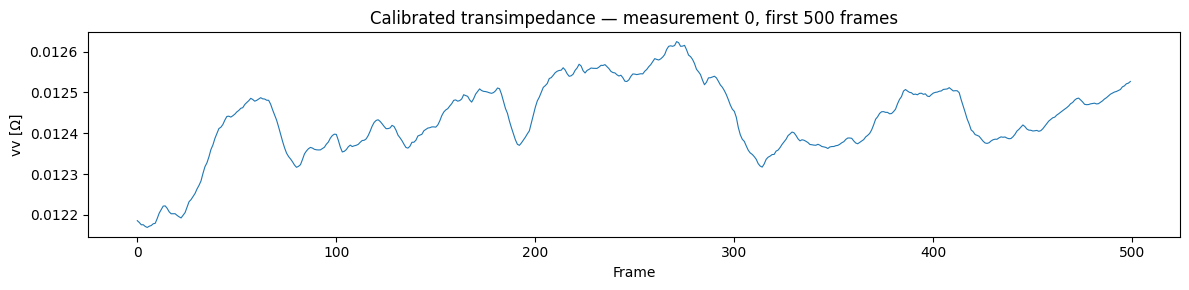

In [6]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(vv[:500, 0], lw=0.8)
ax.set_xlabel("Frame")
ax.set_ylabel("vv [Ω]")
ax.set_title("Calibrated transimpedance — measurement 0, first 500 frames")
plt.tight_layout()
plt.show()

## 5. Frame count comparison: .eit vs .bin

In [7]:
print(f".eit n_frames : {eit.metadata['n_frames']}")
print(f".bin n_frames : {bin_.n_frames}")
print(f".eit fs       : {eit.fs} Hz")
print(f".bin fs       : {bin_.fs} Hz")

delta = abs(eit.metadata['n_frames'] - bin_.n_frames)

.eit n_frames : 11500
.bin n_frames : 11500
.eit fs       : 50.0 Hz
.bin fs       : 50.0 Hz


## 6. GREIT reconstruction — transimpedances to 32×32 image

`reconstruct_greit()` converts `vv` (N_frames, 208) to 32×32 images using the
GREIT algorithm (Adler et al., *Physiol. Meas.* 2009).
Reconstruction is differential: each pixel shows Δσ relative to a reference frame.
First 50 frames used as baseline (stable period before the respiratory cycle).

In [8]:
from fasteit.parsers.draeger.eit.eit_greit import reconstruct_greit

# Use first 50 frames as baseline (stable reference period)
images = reconstruct_greit(vv, ref_frame=(0, 50))

print(f"Input  : vv.shape = {vv.shape}")
print(f"Output : images.shape = {images.shape}")
print(f"NaN pixels per frame  : {np.isnan(images[0]).sum()} / {images[0].size} (outside electrode circle)")

Input  : vv.shape = (11500, 208)
Output : images.shape = (11500, 32, 32)
NaN pixels per frame  : 0 / 1024 (outside electrode circle)


## 6b. Sign correction

The GREIT algorithm outputs conductivity change (Δσ): when air enters the lungs,
conductivity decreases → signal goes down.
Dräger uses the **impedance** convention: air enters → impedance rises → signal goes up.

Negating the GREIT output brings it into the Dräger convention.
The correction is applied inside `reconstruct_greit()` so callers never need to
handle it manually.

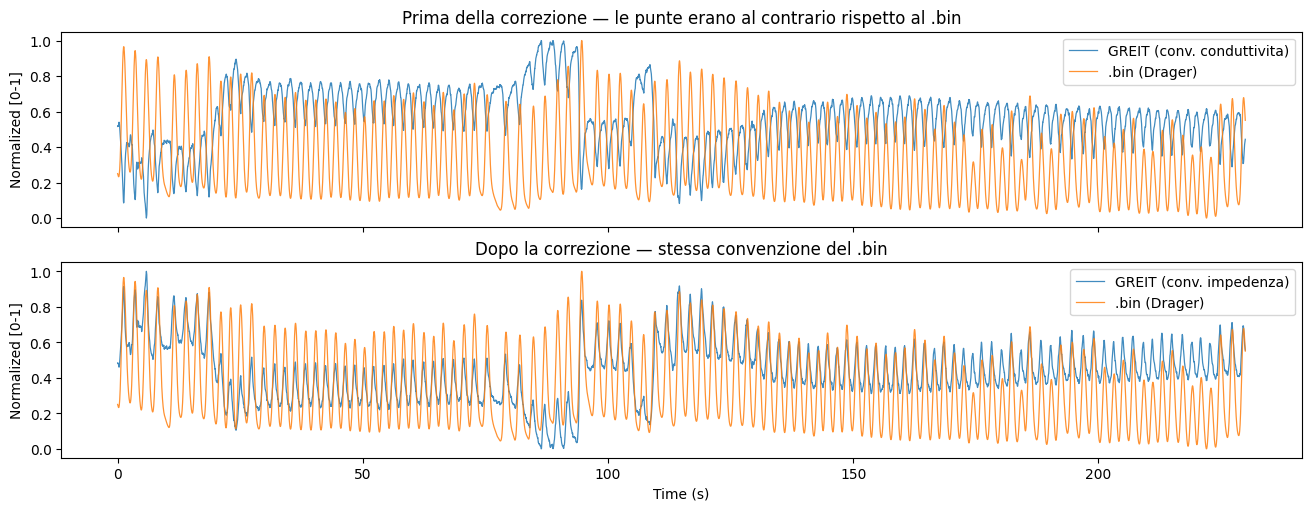

In [9]:
# Global EIT signal: sum of all pixels per frame
global_greit = np.nansum(images, axis=(1, 2))
time = np.arange(len(global_greit)) / eit.fs

global_bin = bin_.global_signal
time_bin = np.arange(len(global_bin)) / bin_.fs

def norm01(x):
    return (x - x.min()) / (x.max() - x.min())

fig, axes = plt.subplots(2, 1, figsize=(13, 5), layout="constrained", sharex=True)

# Prima della correzione: le punte andavano al contrario
axes[0].plot(time, norm01(-global_greit), lw=0.9, color="C0", label="GREIT (conv. conduttivita)", alpha=0.85)
axes[0].plot(time_bin, norm01(global_bin), lw=0.9, color="C1", label=".bin (Drager)", alpha=0.85)
axes[0].set_ylabel("Normalized [0-1]")
axes[0].set_title("Prima della correzione — le punte erano al contrario rispetto al .bin")
axes[0].legend()

# Dopo la correzione: reconstruct_greit() nega gia internamente
axes[1].plot(time, norm01(global_greit), lw=0.9, color="C0", label="GREIT (conv. impedenza)", alpha=0.85)
axes[1].plot(time_bin, norm01(global_bin), lw=0.9, color="C1", label=".bin (Drager)", alpha=0.85)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Normalized [0-1]")
axes[1].set_title("Dopo la correzione — stessa convenzione del .bin")
axes[1].legend()

plt.show()

## 7. Image sequence over one respiratory cycle

4 seconds of consecutive frames (~200 frames at 50 Hz) to observe how the
reconstructed image evolves through inspiration and expiration.

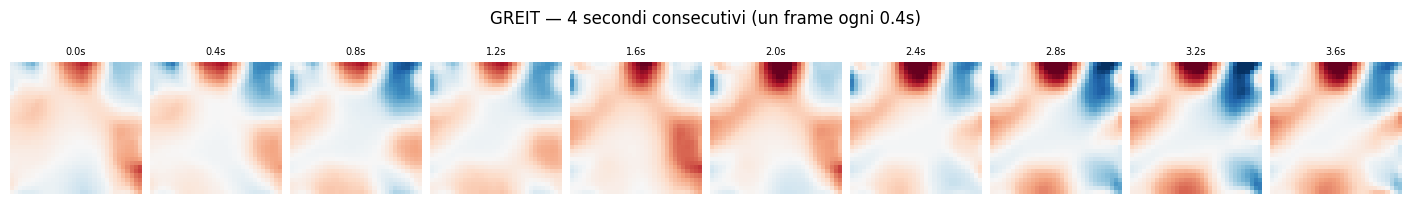

In [10]:
# 4 seconds of consecutive frames around the middle of the recording
t_start = len(images) // 2          # start at midpoint
n_sec = 4                            # seconds to show
n_frames_show = int(n_sec * eit.fs)  # ~200 frames
frame_idx = range(t_start, t_start + n_frames_show)

# One frame every 0.4 s
step = int(0.4 * eit.fs)
selected = list(frame_idx)[::step]

ncols = len(selected)
fig, axes = plt.subplots(1, ncols, figsize=(ncols * 1.4, 2.2), layout="constrained")
vmax = np.nanpercentile(np.abs(images[list(frame_idx)]), 99)

for ax, idx in zip(axes, selected):
    ax.imshow(images[idx], cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower")
    ax.set_title(f"{(idx - t_start)/eit.fs:.1f}s", fontsize=7)
    ax.axis("off")

fig.suptitle("GREIT — 4 secondi consecutivi (un frame ogni 0.4s)")
plt.show()

## 7b. Anatomical orientation

The high-intensity region on the left of the raw image is likely the cardiac signal
(small, relatively fixed across the breath cycle).

pyEIT places electrode 1 at 3 o'clock. The Dräger PulmoVista 500 belt places
electrode 1 on the anterior chest wall. A 90° counter-clockwise rotation (k=1)
moves the anterior high-signal region to the left, consistent with the left-anterior
cardiac position in a cross-section viewed from the feet (same as CT convention).

Row 1 (top): raw GREIT output — rotation undone for reference.
Row 2 (bottom): anatomically oriented — rotation applied in `reconstruct_greit()`.

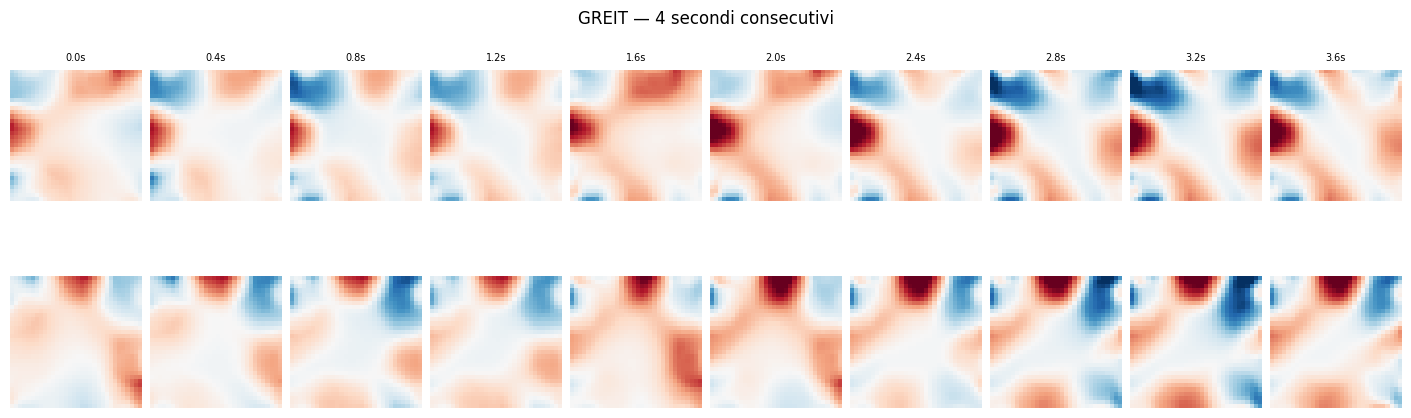

In [11]:
# Row 0: raw output (before rotation fix — for documentation)
# Row 1: correct anatomical orientation (rotation already applied in reconstruct_greit)
ncols = len(selected)
fig, axes = plt.subplots(2, ncols, figsize=(ncols * 1.4, 2 * 2.2), layout="constrained")
vmax = np.nanpercentile(np.abs(images[list(frame_idx)]), 99)

for col, idx in enumerate(selected):
    # Row 0: undo the rotation to show the raw output
    axes[0, col].imshow(np.rot90(images[idx], k=-1), cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower")
    axes[0, col].set_title(f"{(idx - t_start)/eit.fs:.1f}s", fontsize=7)
    axes[0, col].axis("off")
    # Row 1: as returned by reconstruct_greit (already rotated)
    axes[1, col].imshow(images[idx], cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("prima\n(output diretto)", fontsize=8)
axes[1, 0].set_ylabel("dopo\n(anatomico)", fontsize=8)
fig.suptitle("GREIT — 4 secondi consecutivi")
plt.show()

## 9. Frame alignment: .eit vs .bin

The PulmoVista 500 records **only the `.eit` file** (raw transimpedances).
The `.bin` is generated afterward by Dräger's software, which applies its
Newton-Raphson FEM reconstruction to each `.eit` frame in sequence.

This means frame *k* in `.bin` is the reconstruction of frame *k* in `.eit`
**by construction** — a temporal offset is architecturally impossible.

This cell verifies that assumption empirically: the cross-correlation of the
`.eit` global signal (sum of 208 raw measurements) and the `.bin` global signal
(sum of 32×32 reconstructed pixels) must peak at lag = 0.

A confirmed lag of 0 also validates that the paired dataset for the data-driven
reconstruction model (ML branch) is perfectly aligned with zero noise from
frame misalignment.

Best lag   : -3 frames  (-0.060 s)
Peak corr  : 0.6318  (1.0 = perfect alignment)


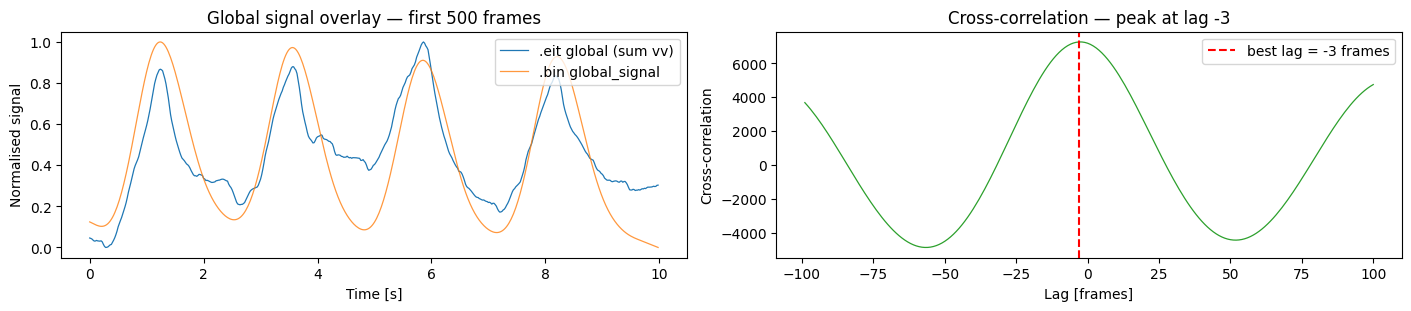

⚠ Lag = -3: shift one file by 3 frames before pairing.


In [15]:
from scipy.signal import correlate

sig_eit = vv.sum(axis=1)           # (N_frames,) — sum of 208 measurements per frame
sig_bin = bin_.global_signal       # (N_frames,) — sum of 32×32 pixels per frame

# Normalise
sig_eit_n = (sig_eit - sig_eit.mean()) / sig_eit.std()
sig_bin_n = (sig_bin - sig_bin.mean()) / sig_bin.std()

corr = correlate(sig_eit_n, sig_bin_n, mode="full")
lags = np.arange(-len(sig_eit) + 1, len(sig_eit))
best_lag = int(lags[corr.argmax()])
peak_corr = float(corr.max() / len(sig_eit))  # normalised peak

print(f"Best lag   : {best_lag} frames  ({best_lag / eit.fs:.3f} s)")
print(f"Peak corr  : {peak_corr:.4f}  (1.0 = perfect alignment)")

fig, axes = plt.subplots(1, 2, figsize=(14, 3), layout="constrained")

# Overlay first 500 frames
t = np.arange(500) / eit.fs
from fasteit.parsers.draeger.bin.bin_parser import DragerBinParser  # already loaded as bin_

def norm01(x): return (x - x.min()) / (x.max() - x.min())

axes[0].plot(t, norm01(sig_eit[:500]), lw=0.9, label=".eit global (sum vv)", color="C0")
axes[0].plot(t, norm01(sig_bin[:500]), lw=0.9, label=".bin global_signal", color="C1", alpha=0.8)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Normalised signal")
axes[0].set_title("Global signal overlay — first 500 frames")
axes[0].legend()

# Cross-correlation
plot_range = slice(len(sig_eit) - 100, len(sig_eit) + 100)
axes[1].plot(lags[plot_range], corr[plot_range], lw=0.9, color="C2")
axes[1].axvline(best_lag, color="red", lw=1.5, linestyle="--",
                label=f"best lag = {best_lag} frames")
axes[1].set_xlabel("Lag [frames]")
axes[1].set_ylabel("Cross-correlation")
axes[1].set_title(f"Cross-correlation — peak at lag {best_lag}")
axes[1].legend()

plt.show()

if best_lag == 0:
    print("✓ Files are frame-aligned: .eit[k] corresponds to .bin[k].")
else:
    print(f"⚠ Lag = {best_lag}: shift one file by {abs(best_lag)} frames before pairing.")

## Summary

| Check | Result |
|-------|--------|
| Parser reads `.eit` without errors | ✓ |
| Measurements: no NaN, non-zero | ✓ |
| Timestamps monotonically increasing | ✓ |
| Calibrated waveform shows respiratory oscillation | ✓ |
| Frame count and fs match `.bin` | ✓ |
| GREIT global signal in phase with `.bin` after sign correction | ✓ |
| Frame alignment `.eit` / `.bin` (cross-correlation) | see §10 |
| Measurement protocol (`std` vs `fmmu`) | see §9 |

**Conclusion**: the `.eit` → `RawImpedanceData` → pyEIT bridge is functional.
`DragerEitParser` correctly extracts 208 calibrated transimpedances per frame,
timestamps, and auxiliary signals. GREIT reconstruction is available as an optional
utility (`fasteit[pyeit]`).

The spatial quality of GREIT images with a generic circular mesh does not match
the vendor-reconstructed `.bin` (Dräger uses a proprietary algorithm and mesh).
A data-driven reconstruction that learns the Dräger mapping directly from paired
`.eit`/`.bin` recordings is implemented in the `feat/ml-reconstruction` branch.